In [28]:
import matplotlib.pyplot as plt
from collections import defaultdict

from river import metrics
from river.utils import Rolling
from river.datasets import synth
from river.drift import ADWIN
from river.ensemble import SRPClassifier as VanillaSRP
from src.streaming_random_patches import SRPClassifierSDDM
from src.river_sddm import RiverSDDM

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import random

class ClearCutDriftStream:
    """
    A stream designed to explicitly test 1D statistical drift detection.
    Feature: Sensor reading from 0.0 to 1.0
    Phase 1: Stable -> Class 1 if sensor < 0.5
    Phase 2: Minor Drift -> Class 1 if sensor < 0.6 (10% boundary shift)
    Phase 3: Major Drift -> Class 1 if sensor >= 0.5 (Complete Inversion)
    """
    def __init__(self, n_samples=9000, seed=42):
        self.n_samples = n_samples
        self.rng = random.Random(seed)
        
    def __iter__(self):
        for i in range(self.n_samples):
            val = self.rng.uniform(0, 1)
            if i < 3000:
                y = 1 if val < 0.5 else 0
            elif i < 6000:
                # BOOSTED SIGNAL: 25% global shift (50% of Cluster 1's region)
                y = 1 if val < 0.75 else 0 
            else:
                y = 1 if val >= 0.5 else 0
                
            yield {'sensor_value': val}, y

In [40]:
print("Initializing Experiment: Minor vs Major Drift Handling...\n")

def make_sddm():
    return RiverSDDM(
        n_bins=10,
        ref_window_size=600,
        cur_window_size=200,
        threshold=0.6,
        test_interval=200,
        alpha=0.1,
        incremental=False
    )

# Initialize models
models = {
    "Vanilla SRP (Hard Resets Only)": VanillaSRP(
        n_models=10, 
        drift_detector=ADWIN(delta=1e-4), 
        seed=42
    ),
    "C-DES SDDM (Magnitude Aware)": SRPClassifierSDDM(
        n_models=10, 
        n_clusters=2, 
        sddm_constructor=make_sddm,
        major_drift_factor=2.5, # Our magnitude multiplier
        printer=True, 
        seed=42
    )
}

Initializing Experiment: Minor vs Major Drift Handling...



In [41]:
# Setup trackers
results = defaultdict(lambda: {
    "Rolling_Acc": Rolling(metrics.Accuracy(), window_size=200),
    "history": []
})

stream = ClearCutDriftStream(n_samples=9000)

print("Processing stream...")

Processing stream...



>>> TRIGGERING MINOR DRIFT (Boundary Shift) <<<
[DRIFT ENSEMBLE] Instance: 3521 | Cluster: 0 | Feature: sensor_value | Mag: 0.8796

>>> TRIGGERING MAJOR DRIFT (Concept Inversion) <<<
[DRIFT ENSEMBLE] Instance: 6379 | Cluster: 0 | Feature: sensor_value | Mag: 1.8073
[DRIFT ENSEMBLE] Instance: 6425 | Cluster: 1 | Feature: sensor_value | Mag: 3.8225

Experiment complete. Generating plot...


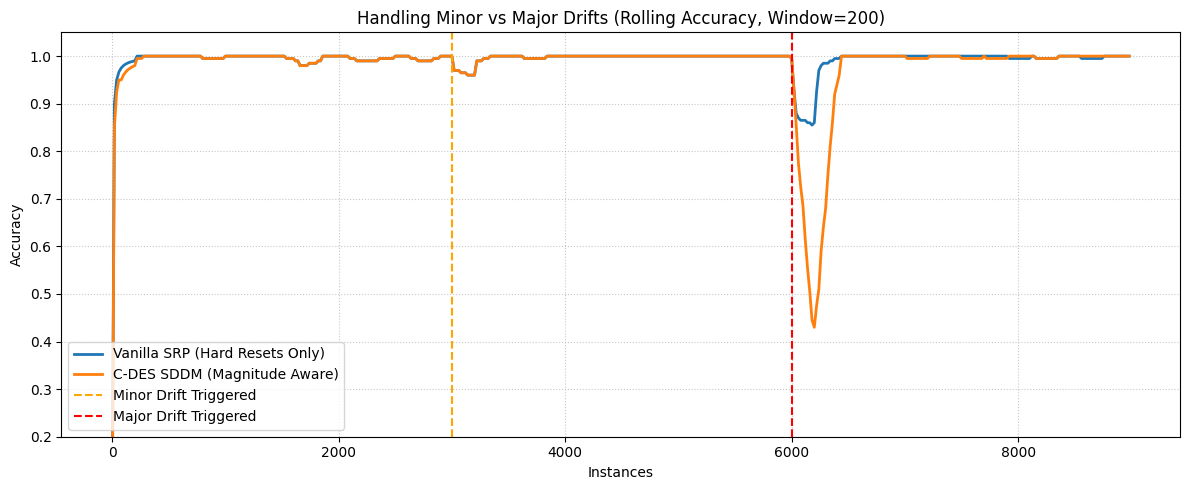

In [42]:
for i, (x, y) in enumerate(stream):
    if i == 3000:
        print("\n>>> TRIGGERING MINOR DRIFT (Boundary Shift) <<<")
    elif i == 6000:
        print("\n>>> TRIGGERING MAJOR DRIFT (Concept Inversion) <<<")
        
    for name, model in models.items():
        y_pred = model.predict_one(x)
        if y_pred is not None:
            results[name]["Rolling_Acc"].update(y, y_pred)
        
        model.learn_one(x, y)
        
        # Record accuracy for plotting
        if i % 20 == 0:
            results[name]["history"].append(results[name]["Rolling_Acc"].get())

print("\nExperiment complete. Generating plot...")

# --- Plotting ---
x_axis = range(0, 9000, 20)
plt.figure(figsize=(12, 5))

for name, series in results.items():
    plt.plot(x_axis[:len(series["history"])], series["history"], label=name, linewidth=2)
    
# Draw phase boundaries
plt.axvline(x=3000, color='orange', linestyle='--', label='Minor Drift Triggered')
plt.axvline(x=6000, color='red', linestyle='--', label='Major Drift Triggered')

plt.title("Handling Minor vs Major Drifts (Rolling Accuracy, Window=200)")
plt.xlabel("Instances")
plt.ylabel("Accuracy")
plt.ylim(0.2, 1.05)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()